In [3]:
import numpy as np
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from typing import Optional

In [4]:
# ----------------------------
# Constants (SI)
# ----------------------------

h = 6.62607015e-34
hbar = h / (2.0 * np.pi)
e = 1.602176634e-19
Phi0 = h / (2.0 * e)

# ----------------------------
# Nonlinear branch energy f(phi, phi_e) and analytic derivatives
# phi is dimensionless phase; phi_e is external flux through both loops in total in units of Phi0 (dimensionless)
# ----------------------------
def f(phi, phi_e, EL, EJ):
    return 0.5 * EL * phi**2 - 2.0 * EJ * np.cos(np.pi * phi_e) * np.cos(phi)

def df(phi, phi_e, EL, EJ):
    return EL * phi + 2.0 * EJ * np.cos(np.pi * phi_e) * np.sin(phi)

def d2f(phi, phi_e, EL, EJ):
    return EL + 2.0 * EJ * np.cos(np.pi * phi_e) * np.cos(phi)

# ----------------------------
# Full constrained potential:
# phi_total = phi1 + phi2 + ... + phiN, eliminate phi1 = phi_total - sum(phi_extra)
# x = phi_extra = [phi2, phi3, ..., phiN] has length N-1
# phi_e_array has length N is the external flux for each branch
# ----------------------------
def U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    U = f(phi1, phi_e_array[0], EL, EJ)
    for i in range(x.size):
        U += f(x[i], phi_e_array[i + 1], EL, EJ)
    return U

def grad_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    df_phi1 = df(phi1, phi_e_array[0], EL, EJ)
    g = np.empty_like(x, dtype=float)
    for i in range(x.size):
        g[i] = -df_phi1 + df(x[i], phi_e_array[i + 1], EL, EJ)
    return g

def hess_U_full(phi_total, x, phi_e_array, EL, EJ):
    phi1 = phi_total - np.sum(x)
    a = d2f(phi1, phi_e_array[0], EL, EJ)  # all off-diagonal entries are a
    n = x.size
    H = np.full((n, n), a, dtype=float)
    for i in range(n):
        H[i, i] = a + d2f(x[i], phi_e_array[i + 1], EL, EJ)
    return H

# ----------------------------
# Minimization domain / periodicity for phase-like variables
# ----------------------------
phi_period = 2.0 * np.pi
phi_min_domain = -0.5 * phi_period
phi_max_domain =  0.5 * phi_period

# n_starts is the number of random restarts for global optimization; seed is for reproducibility
# phi_total is the coordinate we want to keep; x are the extra coordinates we minimize out
# phi_e_array is the external flux for each branch (length N_potential), this is fixed for the whole optimization
def minimize_phi_extra(phi_total, phi_e_array, x0, N_potential, EL, EJ, n_starts, seed, options = None):
    rng = np.random.default_rng(seed)
    n_extra = N_potential - 1

    # objective / derivatives for scipy
    def obj(x):
        return float(U_full(phi_total, x, phi_e_array, EL, EJ))

    def jac(x):
        return grad_U_full(phi_total, x, phi_e_array, EL, EJ)

    def hess(x):
        return hess_U_full(phi_total, x, phi_e_array, EL, EJ)

    best_x = None
    best_fun = np.inf

    # random-restart global search: sample x0 uniformly, run local minimizer, keep best
    for i in range(n_starts):
        if i == 0 and x0 is not None:
            x0 = np.array(x0, dtype=float)
        else:
            x0 = rng.uniform(phi_min_domain, phi_max_domain, size=n_extra)

        res = minimize(
            obj,
            x0,
            method="trust-exact",      # uses analytic jac + hess
            jac=jac,
            hess=hess,
            options=options,
        )

        if res.fun < best_fun:
            best_fun = float(res.fun)
            best_x = np.array(res.x, dtype=float)
    
    best_x = np.mod(best_x - phi_min_domain, phi_period) + phi_min_domain

    return best_x, best_fun

# ----------------------------
# Compute the effective 1D potential U_eff(phi_total) by minimizing out internal degrees of freedom
# 
# This performs a "Born-Oppenheimer" approximation: at each value of the total flux phi_total,
# we minimize over the internal flux distributions [phi2, phi3, ..., phiN] to find the 
# ground-state energy. This reduces the N-dimensional problem to an effective 1D problem.
#
# The result U_eff(phi_total) is the potential energy surface that the system sees when 
# the internal coordinates have relaxed to their optimal configuration.
# ----------------------------

# phi_grid is the array of total flux values we want to evaluate U_eff at
# phi_e_array is the external flux for each branch (length N_potential), this is fixed
# N_potential is the total number of branches (including phi1), EL and EJ are the energy scales
def compute_Ueff(phi_grid, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=None):
    # Pre-allocate arrays to store results at each grid point
    Ueff = np.empty_like(phi_grid, dtype=float)                      # effective 1D potential energy
    x_star = np.empty((phi_grid.size, N_potential - 1), dtype=float) # optimal internal coordinates. Row i is the optimal [phi2, phi3, ..., phiN] for phi_total = phi_grid[i]
    
    # Warm-start optimization: use previous point's solution as initial guess for next point
    # This helps the optimizer follow the same energy minimum branch smoothly along phi_total
    x_prev = None
    
    for i, phi_total in enumerate(phi_grid):
        # Minimize U_full over internal coordinates x = [phi2, ..., phiN] at fixed phi_total
        x_opt, U_opt = minimize_phi_extra(phi_total, phi_e_array, x_prev, N_potential, EL, EJ, n_starts, seed, options=options)
        
        # Store the minimized energy and optimal internal coordinates
        x_star[i, :] = x_opt   # optimal flux distribution at this phi_total
        Ueff[i] = U_opt        # minimum energy = effective potential
        
        # Use this solution to initialize the next optimization step (warm start)
        x_prev = x_opt
    
    return Ueff, x_star

# ----------------------------
# Diagonalize the 1D quantum Hamiltonian H = 4*EC*n^2 + U_eff(phi) using finite differences
#
# The number operator n = -i*d/dphi becomes a discretized derivative, so the kinetic energy
# 4*EC*n^2 = -4*EC*d²/dphi² is represented by a finite-difference Laplacian matrix.
#
# We impose Dirichlet (zero) boundary conditions: ψ(phi_min) = ψ(phi_max) = 0
# This is appropriate when U_eff → ∞ at the boundaries, confining the wavefunction.
#
# order=3: Standard 3-point stencil (2nd-order accurate), gives tridiagonal matrix
# order=5: Higher-accuracy 5-point stencil (4th-order accurate), gives pentadiagonal matrix
# ----------------------------
def diagonalize_fd(phi_grid, Ueff, EC, n_levels, order):
    dphi = phi_grid[1] - phi_grid[0]  # uniform grid spacing
    
    # Enforce Dirichlet (zero) boundary conditions by excluding boundary points
    # We only solve for the wavefunction at interior points: phi_grid[1:-1]
    U_in = Ueff[1:-1]  # potential on interior points, excludes the two boundaries where ψ=0
    N = U_in.size      # number of interior points
    
    # KE and U_in properly account for the potential = 0 at boundaries
    if order == 3: 
        # Standard 3-point centered difference: ψ'' ≈ (ψ_{i-1} - 2ψ_i + ψ_{i+1})/dphi²
        # Kinetic energy: -4*EC*d²/dphi² → diagonal: +8*EC/dphi², off-diag: -4*EC/dphi²
        main = (8.0 * EC / dphi**2) + U_in      # diagonal: kinetic + potential
        off1 = (-4.0 * EC / dphi**2) * np.ones(N - 1)  # nearest-neighbor coupling due to kinetic energy
        H = diags([off1, main, off1], offsets=[-1, 0, 1], format="csc")
    
    elif order == 5:
        # 5-point stencil for higher accuracy (4th-order in interior):
        # ψ'' ≈ (-ψ_{i+2} + 16ψ_{i+1} - 30ψ_i + 16ψ_{i-1} - ψ_{i-2}) / (12*dphi²)
        # Multiply by -4*EC to get kinetic energy operator coefficients
        c0 = (10.0 * EC / dphi**2)             # diagonal (note: 30/12 * 4 = 10)
        c1 = (-16.0 * EC / (3.0 * dphi**2))    # ±1 neighbors (16/12 * 4 = 16/3)
        c2 = (1.0 * EC / (3.0 * dphi**2))      # ±2 neighbors (1/12 * 4 = 1/3)
        
        main = c0 + U_in                       # diagonal: kinetic + potential
        off1 = c1 * np.ones(N - 1)            # nearest neighbors
        off2 = c2 * np.ones(N - 2)            # next-nearest neighbors
        H = diags([off2, off1, main, off1, off2], offsets=[-2, -1, 0, 1, 2], format="csc")
    
    else:
        raise ValueError("order must be 3 or 5")
    
    # Find the lowest n_levels eigenstates using sparse eigenvalue solver
    # "SA" = smallest algebraic eigenvalues (ground state and low-lying excited states)
    evals, evecs = eigsh(H, k=n_levels, which="SA")
    
    # Sort eigenvalues in ascending order (should already be sorted, but ensure it)
    idx = np.argsort(evals)
    
    return evals[idx], evecs[:, idx]

def full_analysis(phi_total_mag, N_opt, N_fine, phi_e_array, N_potential, EL, EJ, EC, n_levels, order: Optional[int] = 5, n_starts: Optional[int] = 3, seed: Optional[int] = 0, options: Optional[dict] = {"maxiter": 200, "gtol": 1e-8}):

    # coarse grid for minimizing out extra coordinates (expensive)
    phi_total_min = -phi_total_mag * 2 * np.pi
    phi_total_max =  phi_total_mag * 2 * np.pi
    phi_opt = np.linspace(phi_total_min, phi_total_max, N_opt)

    Ueff_opt, x_star = compute_Ueff(phi_opt, phi_e_array, N_potential, EL, EJ, n_starts, seed, options=options)

    # spline onto a finer grid for diagonalization (cheap)
    phi_fine = np.linspace(phi_total_min, phi_total_max, N_fine)
    U_spline = CubicSpline(phi_opt, Ueff_opt, bc_type="natural")
    Ueff_fine = U_spline(phi_fine)

    # diagonalize with non-periodic boundaries
    E_GHz, V = diagonalize_fd(phi_fine, Ueff_fine, EC, n_levels, order)

    return {'phi_fine' : phi_fine, 'Ueff_fine' : Ueff_fine, 'phi_opt' : phi_opt, 'Ueff_opt': Ueff_opt, 'E_GHz' : E_GHz, 'V' : V, 'N_opt' : N_opt, 'N_fine' : N_fine, 'phi_total_min' : phi_total_min, 'phi_total_max' : phi_total_max, 'x_star' : x_star}
    

In [5]:
# ----------------------------
# Circuit parameters
# ----------------------------
# C = 60e-15
# L = 10e-9

# EJ = 12.0 # in GHz
# EL = ((hbar / (2.0 * e)) ** 2 / L) / (h * 1e9)  # convert to GHz
# EC = (e**2 / (2.0 * C))/(h * 1e9)  # convert to GHz

N_potential = 3  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 3.333

EC = 0.1
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target
EJ = EL / EL_EJ_ratio

result = full_analysis(
    phi_total_mag=2, 
    N_opt=40, 
    N_fine=1000, 
    phi_e_array=np.array([0.5, 0.5, 0.5], dtype=float), 
    N_potential=N_potential, 
    EL=EL, 
    EJ=EJ, 
    EC=EC, 
    n_levels=5, 
    order=5, 
    n_starts=1, 
    seed=0,
    options={"maxiter": 100, "gtol": 1e-7}
)

E_GHz = result['E_GHz']

print("Lowest energy levels (GHz):")
for i, Ei in enumerate(E_GHz):
    print(f"  E[{i}] = {Ei:.9f} GHz")

print("\nTransition frequencies (GHz):")
for i in range(1, len(E_GHz)):
    print(f"  f_{i}{i-1} = {E_GHz[i] - E_GHz[i-1]:.9f} GHz")

print("\nAnharmonicity (GHz):")
print(f"  α = {E_GHz[2] - 2*E_GHz[1] + E_GHz[0]:.9f} GHz")


Lowest energy levels (GHz):
  E[0] = 3.249998212 GHz
  E[1] = 9.749987492 GHz
  E[2] = 16.249955353 GHz
  E[3] = 22.749887563 GHz
  E[4] = 29.249769933 GHz

Transition frequencies (GHz):
  f_10 = 6.499989280 GHz
  f_21 = 6.499967862 GHz
  f_32 = 6.499932210 GHz
  f_43 = 6.499882369 GHz

Anharmonicity (GHz):
  α = -0.000021418 GHz


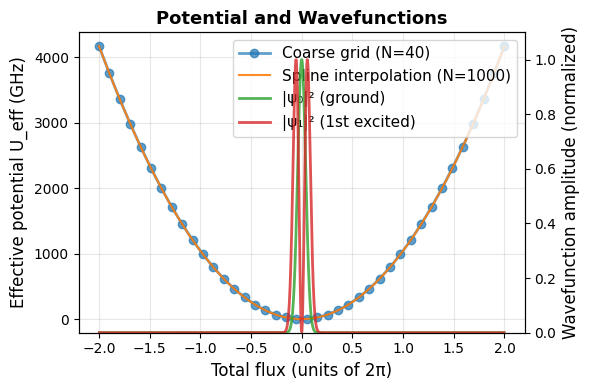

In [6]:
phi_opt = result['phi_opt']
Ueff_opt = result['Ueff_opt']
N_opt = result['N_opt']
phi_fine = result['phi_fine']
Ueff_fine = result['Ueff_fine']
N_fine = result['N_fine']
V = result['V']

# Plot the raw coarse data and the fine spline interpolation with wavefunctions
fig, ax = plt.subplots(figsize=(6, 4))

# Plot raw coarse grid data
ax.plot(phi_opt / (2*np.pi), Ueff_opt, 'o-', linewidth=2, markersize=6, 
        label=f'Coarse grid (N={N_opt})', color='C0', alpha=0.7)

# Plot fine spline interpolation
ax.plot(phi_fine / (2*np.pi), Ueff_fine, '-', linewidth=1.5, 
        label=f'Spline interpolation (N={N_fine})', color='C1', alpha=0.9)

ax.set_xlabel('Total flux (units of 2π)', fontsize=12)
ax.set_ylabel('Effective potential U_eff (GHz)', fontsize=12)
ax.set_title('Potential and Wavefunctions', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for wavefunctions
ax2 = ax.twinx()

# Interior grid points where wavefunctions are defined (exclude boundaries)
phi_interior = phi_fine[1:-1]

# Plot ground state wavefunction (|ψ₀|²)
psi0_sq = V[:, 0]**2
psi0_sq_normalized = psi0_sq / np.max(psi0_sq)  # normalize for visualization
ax2.plot(phi_interior / (2*np.pi), psi0_sq_normalized, '-', linewidth=2, 
         label='|ψ₀|² (ground)', color='C2', alpha=0.8)

# Plot first excited state wavefunction (|ψ₁|²)
psi1_sq = V[:, 1]**2
psi1_sq_normalized = psi1_sq / np.max(psi1_sq)  # normalize for visualization
ax2.plot(phi_interior / (2*np.pi), psi1_sq_normalized, '-', linewidth=2, 
         label='|ψ₁|² (1st excited)', color='C3', alpha=0.8)

ax2.set_ylabel('Wavefunction amplitude (normalized)', fontsize=12)
ax2.set_ylim(0, 1.1)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
print(f"\nCharging energy EC = {EC:.3f} GHz")
print(f"Inductive energy EL = {EL:.3f} GHz")
print(f"Josephson energy EJ = {EJ:.3f} GHz")


Charging energy EC = 0.100 GHz
Inductive energy EL = 158.438 GHz
Josephson energy EJ = 47.536 GHz


Running flux sweep...
  Completed 10/40 flux points
  Completed 20/40 flux points
  Completed 30/40 flux points
  Completed 40/40 flux points
Flux sweep completed!



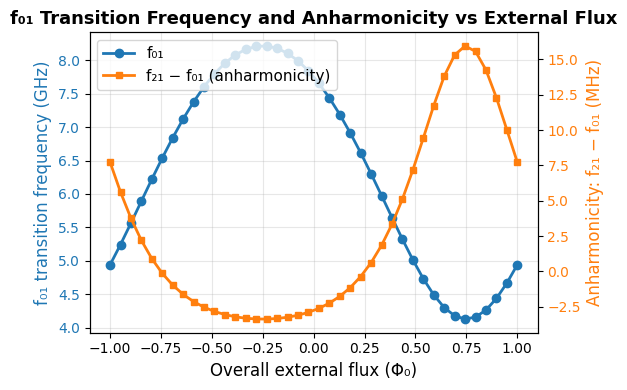

In [10]:
# ----------------------------
# Flux sweep: overall external flux + different initial offsets per loop
# ----------------------------

N_potential = 3  # total number of branches in U = sum_i f(phi_i, phi_ei)

freq = 6.5 # in GHz, at kerr free point
EL_EJ_ratio = 3.333

EC = 0.1
EL_eff_target = freq**2 / (8*EC)     # what the *effective* quadratic coefficient should be
EL = N_potential * EL_eff_target     # branch EL so that EL_eff = EL/N_potential = EL_eff_target
EJ = EL / EL_EJ_ratio

# Define different initial flux offsets for each loop (in units of Phi0)
phi_e_initial = np.array( [0.25, 0.25, 0.25] , dtype=float) # -0.7, +0.1, +0.7 
# Sweep range for overall external flux
phi_ext_sweep = np.linspace(-1, 1, 40)  # sweep flux in units of Phi0

n_levels_sweep = 3  # number of energy levels to compute at each flux point
N_fine = 1000
E_sweep = np.zeros((len(phi_ext_sweep), n_levels_sweep))
Ueff_fine_sweep_all = np.zeros((len(phi_ext_sweep), N_fine))  # store all potentials

print("Running flux sweep...")
for i, phi_ext in enumerate(phi_ext_sweep):
    # Set external flux for each branch: initial offset + overall flux
    phi_e_array_sweep = phi_e_initial + phi_ext
    
    # Compute effective potential
    result = full_analysis(
    phi_total_mag=2, 
    N_opt=40, 
    N_fine=N_fine, 
    phi_e_array=phi_e_array_sweep, 
    N_potential=N_potential, 
    EL=EL, 
    EJ=EJ, 
    EC=EC, 
    n_levels=n_levels_sweep, 
    order=5, 
    n_starts=1, 
    seed=0,
    options={"maxiter": 100, "gtol": 1e-7})
    
    Ueff_fine_sweep_all[i, :] = result["Ueff_fine"]  # store for later plotting
    E_sweep[i, :] = result["E_GHz"]  # store energy levels for this flux point
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{len(phi_ext_sweep)} flux points")

print("Flux sweep completed!\n")

# Plot f_01 transition frequency vs external flux
fig, ax = plt.subplots(figsize=(6, 4))

# Plot f_01 (ground to first excited) on left axis
f01 = E_sweep[:, 1] - E_sweep[:, 0]
ax.plot(phi_ext_sweep, f01, '-o', linewidth=2, markersize=6, color='C0', label='f₀₁')

ax.set_xlabel('Overall external flux (Φ₀)', fontsize=12)
ax.set_ylabel('f₀₁ transition frequency (GHz)', fontsize=12, color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax.set_title('f₀₁ Transition Frequency and Anharmonicity vs External Flux', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Create second y-axis for anharmonicity
ax2 = ax.twinx()

# Plot anharmonicity (f_21 - f_01) on right axis
f21 = E_sweep[:, 2] - E_sweep[:, 1]
anharmonicity = f21 - f01
ax2.plot(phi_ext_sweep, anharmonicity * 1e3, '-s', linewidth=2, markersize=5, color='C1', label='f₂₁ − f₀₁ (anharmonicity)')

ax2.set_ylabel('Anharmonicity: f₂₁ − f₀₁ (MHz)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()
